**Movie Dataset Analysis**

Import Libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

Load Dataset

In [34]:
df = pd.read_csv('credits.csv.zip')
df.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


Basic Exploration

In [35]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45476 entries, 0 to 45475
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cast    45476 non-null  object
 1   crew    45476 non-null  object
 2   id      45476 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


cast    0
crew    0
id      0
dtype: int64

Convert String to List

In [ ]:
df['cast'] = df['cast'].apply(ast.literal_eval)
df['crew'] = df['crew'].apply(ast.literal_eval)

In [ ]:
df['cast'][0]

[{'cast_id': 14,
  'character': 'Woody (voice)',
  'credit_id': '52fe4284c3a36847f8024f95',
  'gender': 2,
  'id': 31,
  'name': 'Tom Hanks',
  'order': 0,
  'profile_path': '/pQFoyx7rp09CJTAb932F2g8Nlho.jpg'},
 {'cast_id': 15,
  'character': 'Buzz Lightyear (voice)',
  'credit_id': '52fe4284c3a36847f8024f99',
  'gender': 2,
  'id': 12898,
  'name': 'Tim Allen',
  'order': 1,
  'profile_path': '/uX2xVf6pMmPepxnvFWyBtjexzgY.jpg'},
 {'cast_id': 16,
  'character': 'Mr. Potato Head (voice)',
  'credit_id': '52fe4284c3a36847f8024f9d',
  'gender': 2,
  'id': 7167,
  'name': 'Don Rickles',
  'order': 2,
  'profile_path': '/h5BcaDMPRVLHLDzbQavec4xfSdt.jpg'},
 {'cast_id': 17,
  'character': 'Slinky Dog (voice)',
  'credit_id': '52fe4284c3a36847f8024fa1',
  'gender': 2,
  'id': 12899,
  'name': 'Jim Varney',
  'order': 3,
  'profile_path': '/eIo2jVVXYgjDtaHoF19Ll9vtW7h.jpg'},
 {'cast_id': 18,
  'character': 'Rex (voice)',
  'credit_id': '52fe4284c3a36847f8024fa5',
  'gender': 2,
  'id': 12900,
 

Top 3 Actors Extract

In [ ]:
def top_actors(x):
    return [i['name'] for i in x[:3]]

df['top_cast'] = df['cast'].apply(top_actors)

print(df[['top_cast']].head(3))

                                         top_cast
0             [Tom Hanks, Tim Allen, Don Rickles]
1  [Robin Williams, Jonathan Hyde, Kirsten Dunst]
2      [Walter Matthau, Jack Lemmon, Ann-Margret]


Extract Director

In [ ]:
def fetch_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']

df['director'] = df['crew'].apply(fetch_director)

df[['director']].head()

,director
0,John Lasseter
1,Joe Johnston
2,Howard Deutch
3,Forest Whitaker
4,Charles Shyer


Top Directors Analysis

In [ ]:
top_directors = df['director'].value_counts().head(10)
print(top_directors)

director
John Ford           66
Michael Curtiz      65
Werner Herzog       54
Alfred Hitchcock    53
Georges Méliès      51
Woody Allen         49
Jean-Luc Godard     47
Sidney Lumet        46
Charlie Chaplin     44
Raoul Walsh         43
Name: count, dtype: int64


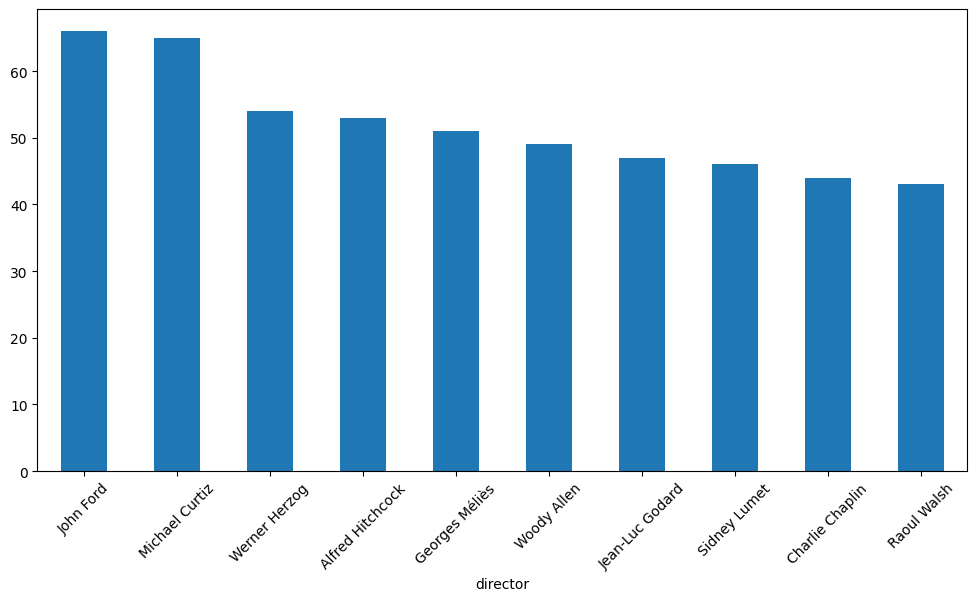

In [ ]:
top_directors.plot(kind='bar', figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

Top Actors Analysis

In [ ]:
actors = []

for i in df['cast']:
    for actor in i[:5]:
        actors.append(actor['name'])

actor_series = pd.Series(actors)

top_actors = actor_series.value_counts().head(10)

print(top_actors)

John Wayne           107
Jackie Chan          101
Christopher Lee       97
Michael Caine         96
Gérard Depardieu      96
Robert De Niro        96
Samuel L. Jackson     84
Donald Sutherland     82
Danny Glover          78
Harvey Keitel         78
Name: count, dtype: int64


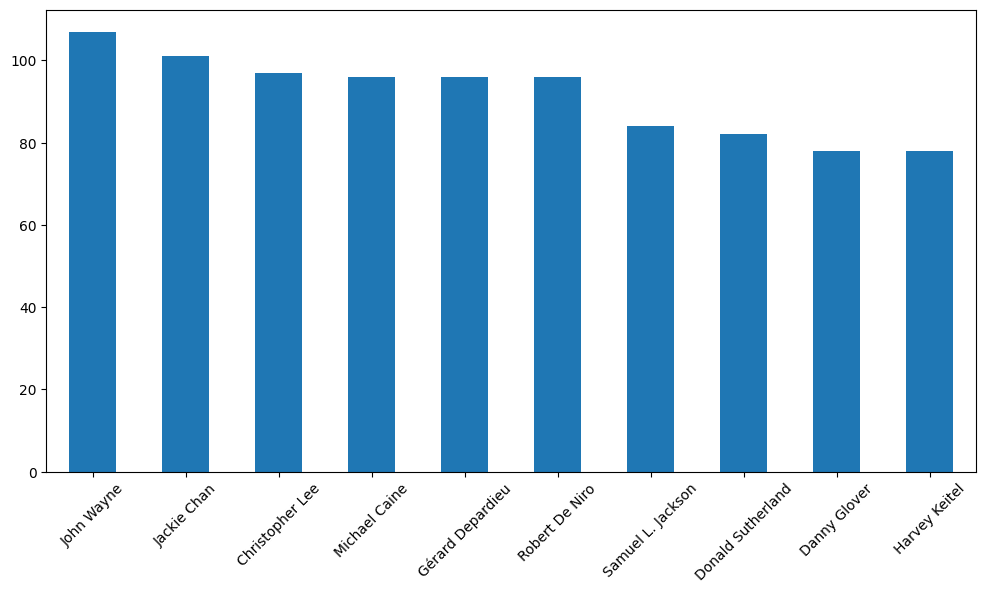

In [ ]:
top_actors.plot(kind='bar', figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

Cast Size Analysis

In [ ]:
df['cast_size'] = df['cast'].apply(len)

df[['cast_size']].sort_values('cast_size', ascending=False).head(10)

,cast_size
925,313
19099,224
927,213
39298,208
20061,208
11266,185
12675,183
17935,172
8366,171
13643,168


Crew Size Analysis

In [ ]:
df['crew_size'] = df['crew'].apply(len)

df[['crew_size']].sort_values('crew_size', ascending=False).head(10)

,crew_size
25083,435
4041,338
44347,316
42181,250
22130,244
4756,242
7718,228
6126,222
9548,220
18252,217


Search Movies by Actor

In [ ]:
actor_name = "Tom Hanks"

movies = df[df['cast'].apply(lambda x: actor_name in [i['name'] for i in x])]
movies

,cast,crew,id,top_cast,director,cast_size,crew_size
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862,"[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,13,106
147,"[{'cast_id': 19, 'character': 'Jim Lovell', 'c...","[{'credit_id': '52fe4253c3a36847f80158f9', 'de...",568,"[Tom Hanks, Bill Paxton, Kevin Bacon]",Ron Howard,27,110
351,"[{'cast_id': 7, 'character': 'Forrest Gump', '...","[{'credit_id': '52fe420ec3a36847f800072d', 'de...",13,"[Tom Hanks, Robin Wright, Gary Sinise]",Robert Zemeckis,66,131
503,"[{'cast_id': 21, 'character': 'Andrew Beckett'...","[{'credit_id': '52fe452fc3a36847f80c10f9', 'de...",9800,"[Tom Hanks, Denzel Washington, Jason Robards]",Jonathan Demme,61,36
534,"[{'cast_id': 13, 'character': 'Sam Baldwin', '...","[{'credit_id': '52fe4283c3a36847f8024b93', 'de...",858,"[Tom Hanks, Meg Ryan, Bill Pullman]",Nora Ephron,23,27
...,...,...,...,...,...,...,...
39486,"[{'cast_id': 0, 'character': 'Chesley 'Sully' ...","[{'credit_id': '561c20b9c3a368225300205a', 'de...",363676,"[Tom Hanks, Aaron Eckhart, Laura Linney]",Clint Eastwood,41,81
40962,"[{'cast_id': 0, 'character': 'Robert Langdon',...","[{'credit_id': '57aead299251410a82001218', 'de...",207932,"[Tom Hanks, Felicity Jones, Omar Sy]",Ron Howard,17,29
42897,"[{'cast_id': 16, 'character': 'Himself', 'cred...","[{'credit_id': '52fe4a909251416c750e6615', 'de...",140465,"[Adam Arkin, Philip Bosco, Patricia Clarkson]",Ken Burns,14,15
43183,"[{'cast_id': 12, 'character': 'Willie Grogan',...","[{'credit_id': '5471ffa7c3a36805d800062a', 'de...",305642,"[Sam Shepard, Hamish Linklater, Alex Neustaedter]",Meg Ryan,18,10


Search Movies by Director

In [ ]:
df[df['director'] == 'Christopher Nolan']

,cast,crew,id,top_cast,director,cast_size,crew_size
2466,"[{'cast_id': 17, 'character': 'Bill', 'credit_...","[{'credit_id': '52fe44739251416c750352fd', 'de...",11660,"[Jeremy Theobald, Alex Haw, Lucy Russell]",Christopher Nolan,15,10
4099,"[{'cast_id': 4, 'character': 'Leonard', 'credi...","[{'credit_id': '52fe4214c3a36847f80024cb', 'de...",77,"[Guy Pearce, Carrie-Anne Moss, Joe Pantoliano]",Christopher Nolan,13,21
5254,"[{'cast_id': 3, 'character': 'Will Dormer', 'c...","[{'credit_id': '52fe4237c3a36847f800ced5', 'de...",320,"[Al Pacino, Robin Williams, Hilary Swank]",Christopher Nolan,25,40
10122,"[{'cast_id': 13, 'character': 'Bruce Wayne / B...","[{'credit_id': '52fe4230c3a36847f800ac6d', 'de...",272,"[Christian Bale, Michael Caine, Liam Neeson]",Christopher Nolan,113,137
11354,"[{'cast_id': 11, 'character': 'Robert Angier',...","[{'credit_id': '52fe42e8c3a36847f802bef9', 'de...",1124,"[Hugh Jackman, Christian Bale, Michael Caine]",Christopher Nolan,41,58
12481,"[{'cast_id': 35, 'character': 'Bruce Wayne / B...","[{'credit_id': '55a0eb4a925141296b0010f8', 'de...",155,"[Christian Bale, Michael Caine, Heath Ledger]",Christopher Nolan,134,81
15480,"[{'cast_id': 1, 'character': 'Dom Cobb', 'cred...","[{'credit_id': '56e8462cc3a368408400354c', 'de...",27205,"[Leonardo DiCaprio, Joseph Gordon-Levitt, Elle...",Christopher Nolan,29,18
18252,"[{'cast_id': 2, 'character': 'Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...",49026,"[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan,158,217
22878,"[{'cast_id': 9, 'character': 'Joseph Cooper', ...","[{'credit_id': '54cba75b925141678e014d1a', 'de...",157336,"[Matthew McConaughey, Jessica Chastain, Anne H...",Christopher Nolan,36,120
25896,"[{'cast_id': 2, 'character': 'The Man', 'credi...","[{'credit_id': '52fe4655c3a36847f80f96bf', 'de...",43629,[Jeremy Theobald],Christopher Nolan,1,12
